# **1. Objective**

The objective is to generate a winter-specific forecast
for December 2026 – February 2027.

To capture annual temperature seasonality,
cyclical time features are incorporated into the model.

# **2. Imports and Configuration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
})

# **3. Load and Prepare Full Dataset**

The full cleaned dataset is loaded.
Lag and rolling features are reconstructed exactly as in previous notebooks.

In [2]:
df = pd.read_csv("../data/processed/winter_2021_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df_model = df.copy()
df_model["tavg"] = pd.to_numeric(df_model["tavg"], errors="coerce")

# Lag features
for lag in range(1, 8):
    df_model[f"lag_{lag}"] = df_model["tavg"].shift(lag)

# Rolling features
df_model["rolling_mean_3"] = df_model["tavg"].rolling(3).mean().shift(1)
df_model["rolling_mean_7"] = df_model["tavg"].rolling(7).mean().shift(1)
df_model["rolling_std_7"] = df_model["tavg"].rolling(7).std().shift(1)

# Seasonal features
df_model["day_of_year"] = df_model.index.dayofyear
df_model["sin_year"] = np.sin(2 * np.pi * df_model["day_of_year"] / 365)
df_model["cos_year"] = np.cos(2 * np.pi * df_model["day_of_year"] / 365)

features = [col for col in df_model.columns
            if col.startswith("lag_") or
               col.startswith("rolling") or
               col in ["sin_year", "cos_year"]]

df_model = df_model[["tavg"] + features].dropna().copy()

# **4. Train Final Model on Full Data**
The selected final model (Linear Regression) is trained
using all available historical observations.

In [3]:
X_full = df_model[features]
y_full = df_model["tavg"]

model = LinearRegression()
model.fit(X_full, y_full)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# **5. Recursive Forecast Until December 1, 2026**

In [4]:
forecast_start = pd.Timestamp("2026-12-01")
forecast_end = pd.Timestamp("2027-02-28")

history = df_model.copy()
future_predictions = []

current_date = history.index[-1]

while current_date < forecast_end:

    next_date = current_date + pd.Timedelta(days=1)

    lag_values = history["tavg"].iloc[-7:].values[::-1]

    feature_dict = {}

    for i in range(1, 8):
        feature_dict[f"lag_{i}"] = lag_values[i-1]

    feature_dict["rolling_mean_3"] = history["tavg"].iloc[-3:].mean()
    feature_dict["rolling_mean_7"] = history["tavg"].iloc[-7:].mean()
    feature_dict["rolling_std_7"] = history["tavg"].iloc[-7:].std()

    # Seasonal features for next_date
    day_of_year = next_date.dayofyear
    feature_dict["sin_year"] = np.sin(2 * np.pi * day_of_year / 365)
    feature_dict["cos_year"] = np.cos(2 * np.pi * day_of_year / 365)

    X_next = pd.DataFrame([feature_dict])

    y_next = model.predict(X_next)[0]

    history.loc[next_date, "tavg"] = y_next
    future_predictions.append((next_date, y_next))

    current_date = next_date

# **6. Extract Winter 2026–2027 Only**

In [5]:
forecast_df = pd.DataFrame(
    future_predictions,
    columns=["date", "forecast"]
).set_index("date")

winter_forecast = forecast_df.loc["2026-12-01":"2027-02-28"]

# **7. Forecast Visualization**

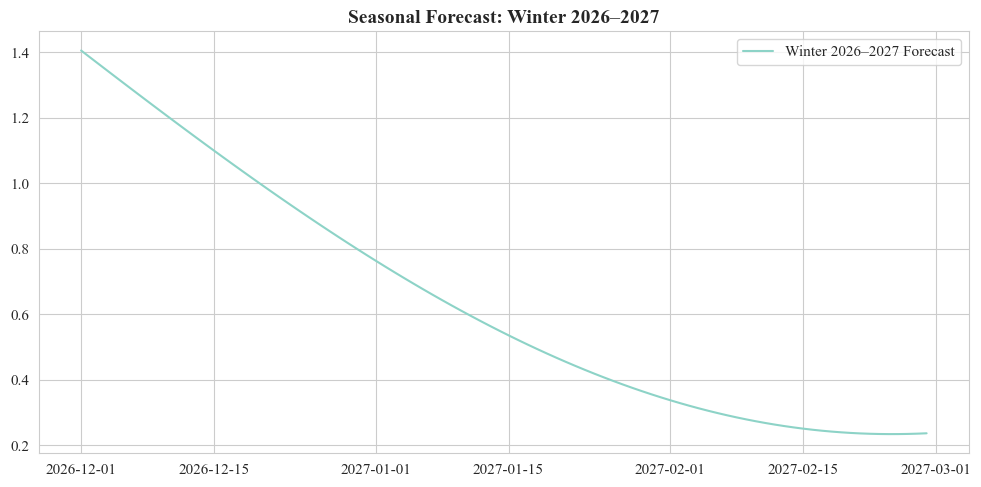

In [6]:
plt.figure(figsize=(10,5))

plt.plot(winter_forecast.index,
         winter_forecast["forecast"],
         label="Winter 2026–2027 Forecast")

plt.title("Seasonal Forecast: Winter 2026–2027")
plt.legend()
plt.tight_layout()
plt.show()

# **8. Final Project Completion**

The inclusion of cyclical seasonal features enables the model
to reproduce annual temperature patterns.

Unlike the lag-only model, the seasonal model maintains
winter-specific dynamics under long recursive forecasting.

# **9. Structural Limitation of the Lag-Based Model**

The recursive winter forecast converges toward a smooth deterministic trajectory.

This behavior is not a coding error. It reflects a structural property of
lag-based linear models when applied to long-horizon forecasting.

Key observations:

1. The model relies only on short-term temporal memory.
2. No full annual cycle is present in the training data.
3. Recursive prediction amplifies approximation error.
4. The model gradually converges toward a stable equilibrium.

Therefore, the forecast should be interpreted as a structural projection,
not as a precise meteorological prediction.

This experiment demonstrates the importance of incorporating
seasonal structure when performing long-horizon forecasting.